In [1]:
import pyAMARES
import numpy as np

pyAMARES.__version__

/home/xujia/miniconda3/envs/py312/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


'0.3.34dev'

# Fitting Simulated In Vivo 31P MRS Data
**[Try This Tutorial on Google Colab!](https://colab.research.google.com/drive/1H8GdP4XX292JovAF5TNOEBaYQT5vk_DT)**

## Simulating an In Vivo MRS Spectrum

- **Load Prior Knowledge**: Use the dataset based on the 7T brain data reported by Ren et al. in NMR Biomedicine, 28(11): 1455–1462.

[AMARES | WARNING] Fid is None! Creating unity array instead.


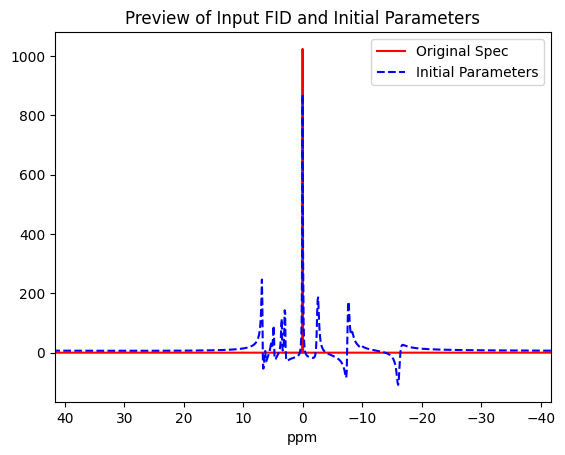

,BATP,BATP2,BATP3,AATP,AATP2,GATP,GATP2,UDPG,NAD,PCr,GPC,GPE,Pin,Pex,PC,PE
Index,,,,,,,,,,,,,,,,
Initial Values,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amplitude,1.41,BATP/2,BATP/2,1.545,AATP,1.5,GATP,0.08,0.41,4.37,1.32,0.8,0.85,0.3,0.3,2.27
chemicalshift,-16.15,BATP-15Hz,BATP+15Hz,-7.49,AATP-16Hz,-2.46,GATP-16Hz,-9.72,-8.25,0.0,2.95,3.5,4.82,5.24,6.24,6.76
linewidth,58.119999,BATP,BATP,32.279999,AATP,39.02,GATP,32.369999,40.490002,15.41,19.959999,19.1,21.040001,30.91,19.959999,22.629999
phase,0.0,BATP,BATP,BATP,BATP,BATP,BATP,BATP,BATP,BATP,BATP,BATP,BATP,BATP,BATP,BATP
g,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Bounds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amplitude,"(0,","(0,","(0,","(0,","(0,","(0,","(0,","(0,","(0,","(0,","(0,","(0,","(0,","(0,","(0,","(0,"
chemicalshift,"(-16.30,-16.00)","(-16.30,-16.00)","(-16.30,-16.00)","(-7.72,-7.42)","(-7.72,-7.42)","(-2.65,-2.39)","(-2.65,-2.39)","(-9.76,-9.68)","(-8.25,-8.17)","(-0.5, 0.5)","(2.94,2.96)","(3.49,3.51)","(4.81,4.83)","(5.19,5.29)","(6.22,6.26)","(6.71,6.81)"


In [2]:
priorknowledge = pyAMARES.initialize_FID(
    fid=None, priorknowledgefile="example_human_brain_31P_7T.csv", preview=True
)

- **Perturb Peak Parameters**: Randomly adjust the 31P spectra peak parameters by 5%, chemical shift by 10 Hz

In [3]:
from copy import deepcopy

In [4]:
params0 = deepcopy(
    priorknowledge.initialParams
)  # Make a copy of initialParams to be perturbed

In [5]:
def perturb_value(value, percentage=5):
    percentage = float(percentage)
    # Generate a random perturbation factor between 0.95 and 1.05
    factor = np.random.uniform(1 - percentage / 100, 1 + percentage / 100)
    # Apply the perturbation factor
    result = value * factor
    # print(f"Perturbing input {value=} to {result=}")
    return result


def perturb_table(inputparams, percentage=5, freq_shift=5, phase_shift=0):
    params = deepcopy(inputparams)
    for i in params:
        if params[i].name.startswith("ak") or params[i].name.startswith("dk"):
            params[i].value = perturb_value(params[i].value)
        if params[i].name.startswith("freq"):
            params[i].value += np.random.uniform(-freq_shift, freq_shift)
        if params[i].name.startswith("phi"):
            params[i].value += np.random.uniform(
                -np.deg2rad(phase_shift), np.deg2rad(phase_shift)
            )
    return params

In [6]:
params = perturb_table(params0, percentage=5, freq_shift=5, phase_shift=0)

- **Simulate the 31P MRS Spectra Using Scanner Parameters**:
    - **MHz (Field Strength)**: 120 MHz, corresponding to 31P at 7T.
    - **sw (Spectral Width)**: 10000.0 Hz.
    - **Deadtime**: 200 microseconds (200e-6 seconds).
    - **Number of Points (fid_len)**: 1024.
    - **SNR (Signal to Noise Ratio, snr_target)**: 20.

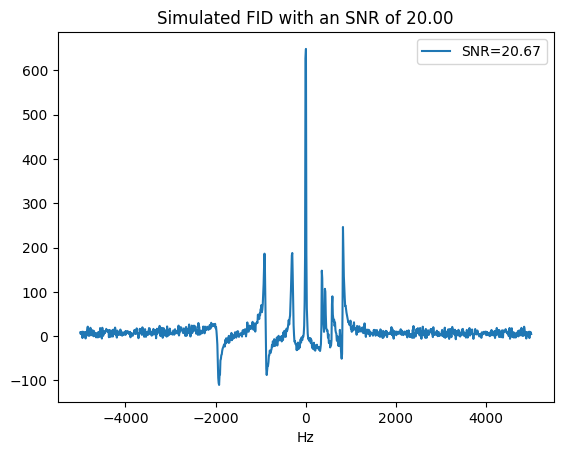

In [7]:
fid = pyAMARES.kernel.fid.simulate_fid(
    params,
    MHz=120.0,
    sw=10000.0,
    deadtime=200e-6,
    fid_len=1024,
    snr_target=20,
    preview=True,
)

## Simple Tutorial on pyAMARES Fitting
- **Initialize the FID Object**: 

In [8]:
FIDobj = pyAMARES.initialize_FID(
    fid=fid,
    MHz=120.0,
    sw=10000.0,
    deadtime=200e-6,
    normalize_fid=False,
    priorknowledgefile="example_human_brain_31P_7T.csv",
    preview=False,
)

- **A. HSVD Optimization of Initial Parameters (Optional)**: Utilize HSVD to optimize the initial parameters for fitting, if desired.

In [9]:
params_hsvd = pyAMARES.HSVDinitializer(
    fid_parameters=FIDobj,
    num_of_component=12,  # If an error happens with preview, decrease this number
    fitting_parameters=FIDobj.initialParams,
    preview=False,
)

- **Fitting AMARES Using HSVD-Initialized Parameters**:

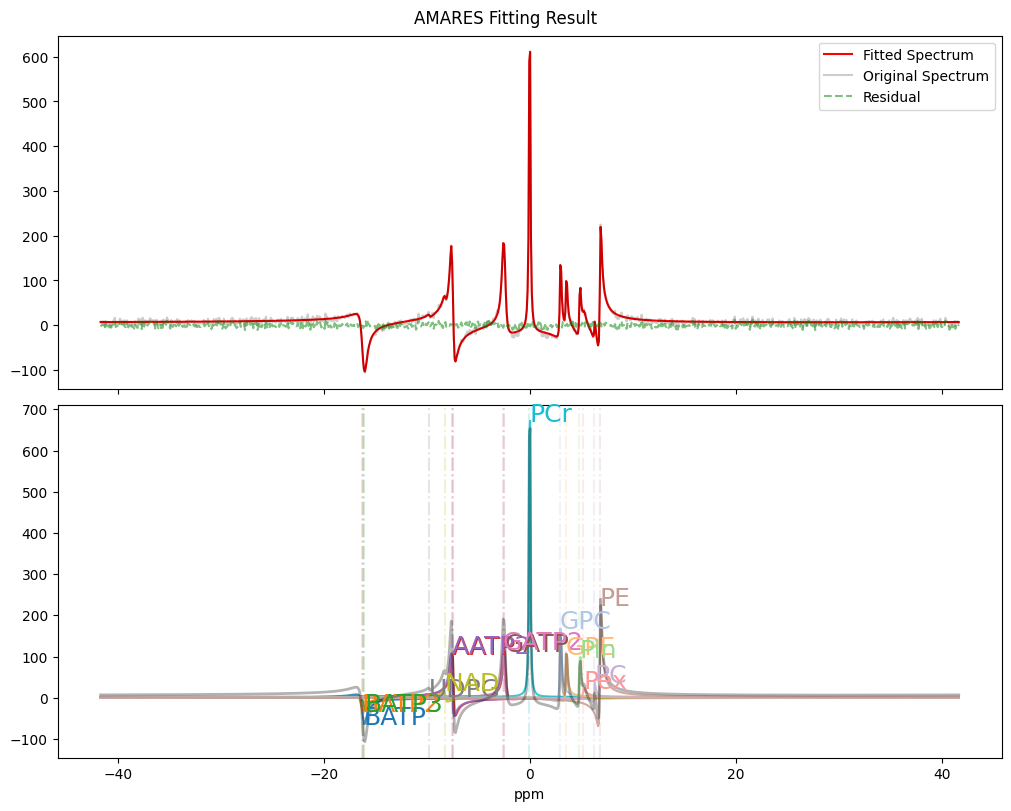

In [10]:
FIDresult1 = pyAMARES.fitAMARES(
    fid_parameters=FIDobj,
    fitting_parameters=params_hsvd,
    method="least_squares",
    ifplot=True,
    inplace=False,
)

In [11]:
FIDresult1.styled_df

,amplitude,sd,CRLB(%),chem shift(ppm),sd(ppm),CRLB(cs%),LW(Hz),sd(Hz),CRLB(LW%),phase(deg),sd(deg),CRLB(phase%),g,g_sd,g (%),SNR
name,,,,,,,,,,,,,,,,
BATP,2.867,0.057,2.795,-16.171,0.005,0.046,60.333,1.872,4.331,-0.378,0.295,108.795,0.000,0.000,nan,10.953
AATP,3.083,0.048,2.187,-7.449,0.002,0.042,31.227,0.827,3.696,-0.378,0.295,108.795,0.000,0.000,nan,11.780
GATP,3.088,0.047,2.112,-2.451,0.003,0.160,38.949,0.959,3.438,-0.378,0.295,108.795,0.000,0.000,nan,11.797
UDPG,0.071,0.037,72.215,-9.760,0.060,0.859,29.125,20.843,99.906,-0.378,0.295,108.795,0.000,0.000,nan,0.271
NAD,0.372,0.052,19.397,-8.247,0.019,0.328,40.787,7.343,25.135,-0.378,0.295,108.795,0.000,0.000,nan,1.421
PCr,4.456,0.026,0.816,-0.039,0.000,1.787,15.408,0.126,1.144,-0.378,0.295,108.795,0.000,0.000,nan,17.024
GPC,1.334,0.032,3.332,2.940,0.002,0.095,21.026,0.692,4.598,-0.378,0.295,108.795,0.000,0.000,nan,5.097
GPE,0.865,0.032,5.136,3.508,0.003,0.120,20.849,1.056,7.073,-0.378,0.295,108.795,0.000,0.000,nan,3.305
Pin,0.831,0.045,7.624,4.813,0.003,0.093,20.545,1.289,8.758,-0.378,0.295,108.795,0.000,0.000,nan,3.176


- **B. Initialization Using Levenberg-Marquardt Method**: Instead of using the HSVD initializer, initialize the parameters using the Levenberg-Marquardt method.

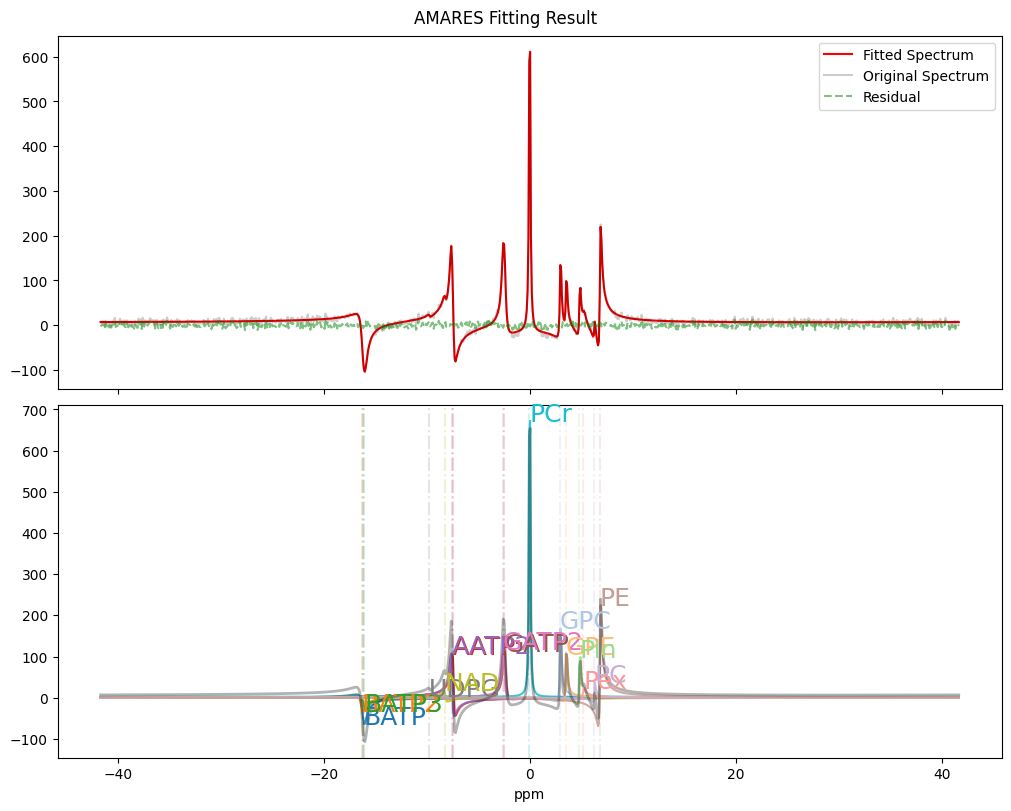

In [12]:
params_LM = pyAMARES.fitAMARES(
    fid_parameters=FIDobj,
    fitting_parameters=FIDobj.initialParams,
    method="leastsq",
    ifplot=True,
    inplace=False,
)

- **Fitting AMARES Using Levenberg-Marquardt-Initialized Parameters**:

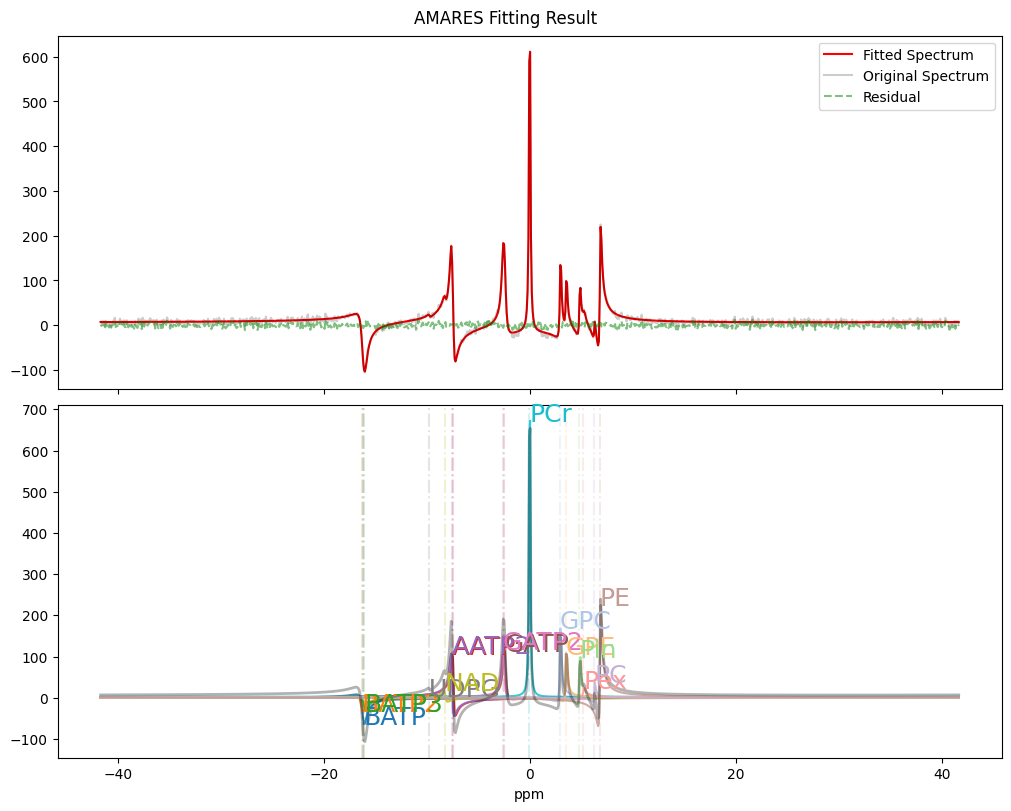

In [13]:
FIDresult2 = pyAMARES.fitAMARES(
    fid_parameters=FIDobj,
    fitting_parameters=params_LM.fittedParams,
    initialize_with_lm=False,
    method="least_squares",
    ifplot=True,
    inplace=False,
)

In [14]:
FIDresult2.styled_df

,amplitude,sd,CRLB(%),chem shift(ppm),sd(ppm),CRLB(cs%),LW(Hz),sd(Hz),CRLB(LW%),phase(deg),sd(deg),CRLB(phase%),g,g_sd,g (%),SNR
name,,,,,,,,,,,,,,,,
BATP,2.867,0.057,2.795,-16.171,0.005,0.046,60.332,1.872,4.331,-0.379,0.295,108.632,0.000,0.000,nan,10.953
AATP,3.083,0.048,2.186,-7.449,0.002,0.042,31.226,0.827,3.696,-0.379,0.295,108.632,0.000,0.000,nan,11.780
GATP,3.088,0.047,2.112,-2.451,0.003,0.160,38.948,0.959,3.438,-0.379,0.295,108.632,0.000,0.000,nan,11.797
UDPG,0.071,0.037,72.211,-9.760,0.060,0.859,29.125,20.842,99.900,-0.379,0.295,108.632,0.000,0.000,nan,0.271
NAD,0.372,0.052,19.393,-8.246,0.019,0.327,40.727,7.332,25.132,-0.379,0.295,108.632,0.000,0.000,nan,1.420
PCr,4.456,0.026,0.816,-0.039,0.000,1.787,15.408,0.126,1.144,-0.379,0.295,108.632,0.000,0.000,nan,17.024
GPC,1.334,0.032,3.332,2.940,0.002,0.095,21.026,0.692,4.598,-0.379,0.295,108.632,0.000,0.000,nan,5.097
GPE,0.865,0.032,5.135,3.508,0.003,0.120,20.849,1.056,7.073,-0.379,0.295,108.632,0.000,0.000,nan,3.305
Pin,0.831,0.045,7.624,4.813,0.003,0.093,20.545,1.289,8.758,-0.379,0.295,108.632,0.000,0.000,nan,3.176


- **New after 0.3.10**: Fitting AMARES using internally initialized Levenberg-Marquardt parameters:

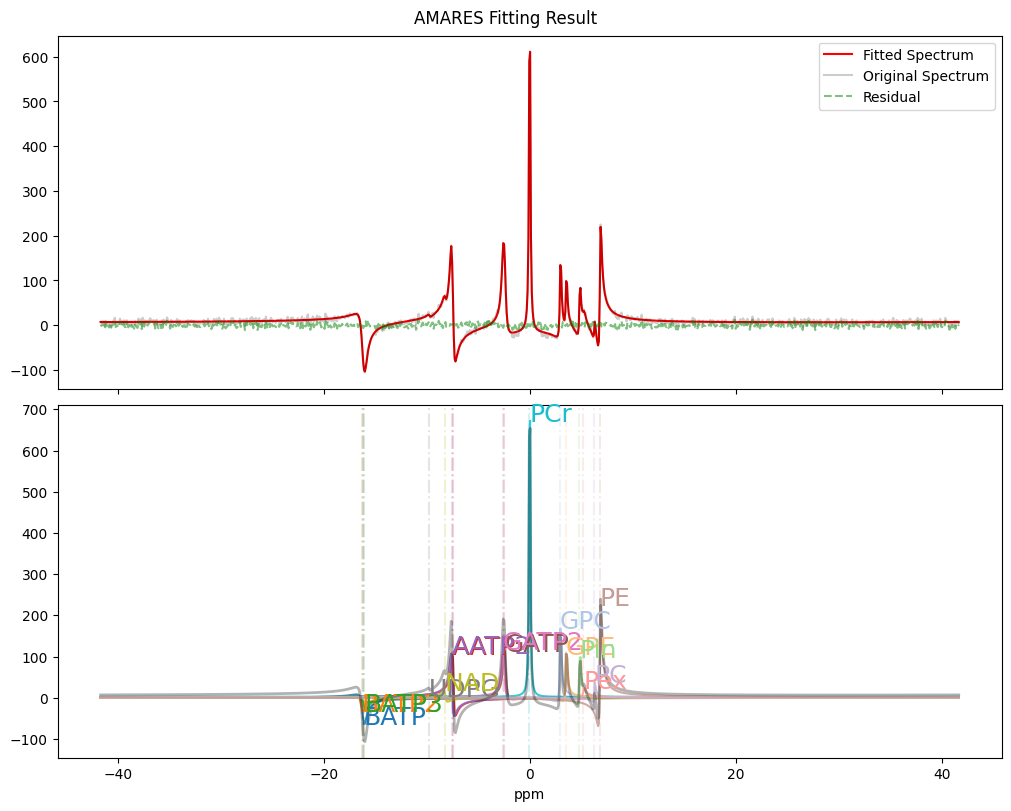

In [15]:
FIDresult2b = pyAMARES.fitAMARES(
    fid_parameters=FIDobj,
    fitting_parameters=FIDobj.initialParams,
    initialize_with_lm=True,  # Turn on the Levenberg-Marquardt initializer
    method="least_squares",
    ifplot=True,
    inplace=False,
)

In [16]:
FIDresult2b.styled_df

,amplitude,sd,CRLB(%),chem shift(ppm),sd(ppm),CRLB(cs%),LW(Hz),sd(Hz),CRLB(LW%),phase(deg),sd(deg),CRLB(phase%),g,g_sd,g (%),SNR
name,,,,,,,,,,,,,,,,
BATP,2.867,0.057,2.795,-16.171,0.005,0.046,60.332,1.872,4.331,-0.379,0.295,108.632,0.000,0.000,nan,10.953
AATP,3.083,0.048,2.186,-7.449,0.002,0.042,31.226,0.827,3.696,-0.379,0.295,108.632,0.000,0.000,nan,11.780
GATP,3.088,0.047,2.112,-2.451,0.003,0.160,38.948,0.959,3.438,-0.379,0.295,108.632,0.000,0.000,nan,11.797
UDPG,0.071,0.037,72.211,-9.760,0.060,0.859,29.125,20.842,99.900,-0.379,0.295,108.632,0.000,0.000,nan,0.271
NAD,0.372,0.052,19.393,-8.246,0.019,0.327,40.727,7.332,25.132,-0.379,0.295,108.632,0.000,0.000,nan,1.420
PCr,4.456,0.026,0.816,-0.039,0.000,1.787,15.408,0.126,1.144,-0.379,0.295,108.632,0.000,0.000,nan,17.024
GPC,1.334,0.032,3.332,2.940,0.002,0.095,21.026,0.692,4.598,-0.379,0.295,108.632,0.000,0.000,nan,5.097
GPE,0.865,0.032,5.135,3.508,0.003,0.120,20.849,1.056,7.073,-0.379,0.295,108.632,0.000,0.000,nan,3.305
Pin,0.831,0.045,7.624,4.813,0.003,0.093,20.545,1.289,8.758,-0.379,0.295,108.632,0.000,0.000,nan,3.176


## Visualize Fitting Results

- **Visualization with pyAMARES**: pyAMARES utilizes the `plotParameter` object to display fitting results visually.
- **Template for `plotParameter`**: Within the initialized `FIDobj`, there is a pre-configured template for `plotParameter` to facilitate customization and usage.

In [17]:
plotParameter = (
    FIDobj.plotParameters
)  # plotParameter is a pointer to FIDobj.plotParameters
# If you do not want to modify FIDobj.plotParameters,
# do plotParameter = deepcopy(FIDobj.plotParameters) instead
plotParameter

Namespace(deadtime=0.0002, lb=2.0, sw=10000.0, xlim=None, ifphase=False)

- **Modify the visualization parameters**

In [18]:
plotParameter.ifphase = True  # Phasing the spectrum for visualization
plotParameter.xlim = (10, -20)  # Show 10 to -20 ppm only

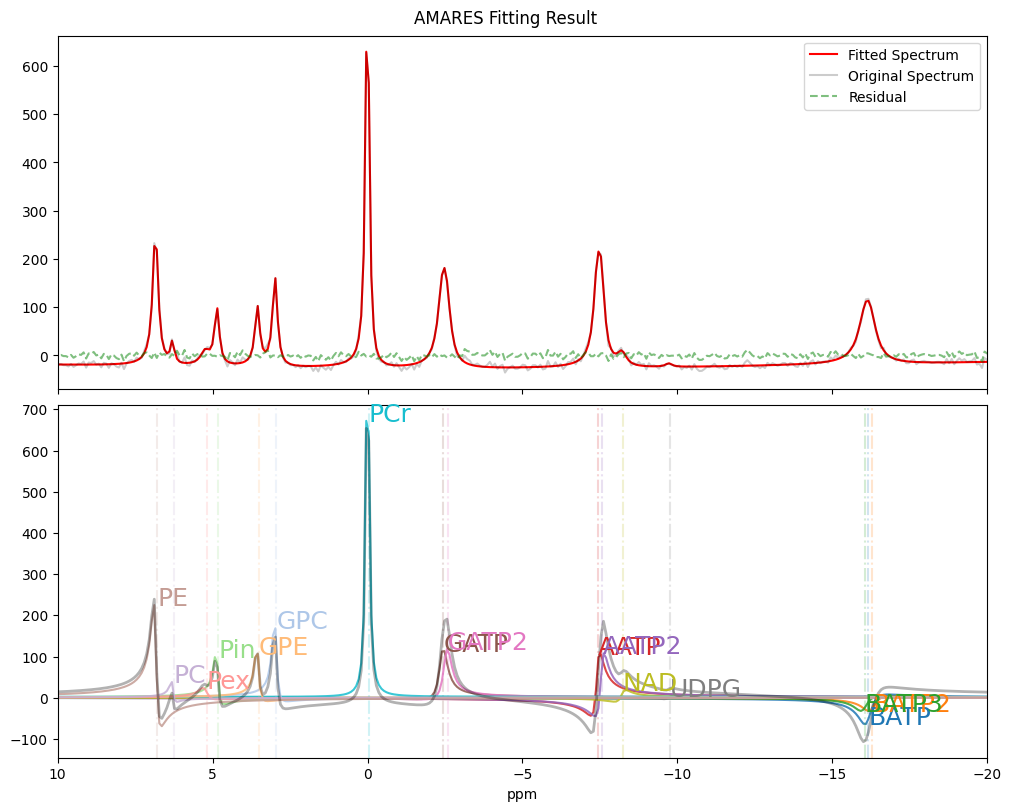

In [19]:
pyAMARES.plotAMARES(FIDresult2, plotParameters=plotParameter)

- **Uniform Phase for All Peaks**: Previously, each peak's phase was fitted independently. We can now attempt to use the same phase for all peaks.
- **Editing Parameters**: Parameters can be edited programmatically using Python. Alternatively, you can manually edit them using Excel or similar software. Use the `pyAMARES.kernel.lmfit.save_parameter_to_csv` function to save parameters to a CSV file, and `pyAMARES.kernel.lmfit.load_parameter_from_csv` to reload them as an lmfit parameter object.
``

In [20]:
initial_params_fixedphase = deepcopy(
    params_LM.fittedParams
)  # Starting from the Levenberg-Marquardt-Initialized Parameters

In [21]:
# Constrain all phase parameters (starting with `phi` ) to the phase of PCr (`phi_Pcr`)
for peak_para in initial_params_fixedphase:
    if peak_para.startswith("phi"):
        initial_params_fixedphase[peak_para].expr = "phi_PCr"

In [22]:
# But do not fix phi_PCr itself because it will be fitted
initial_params_fixedphase["phi_PCr"].expr = None
initial_params_fixedphase["phi_PCr"].vary = True

- If you modified the `FIDobj.plotParameters` above and turned on `ifphase`, the following preview will show phased spectrum

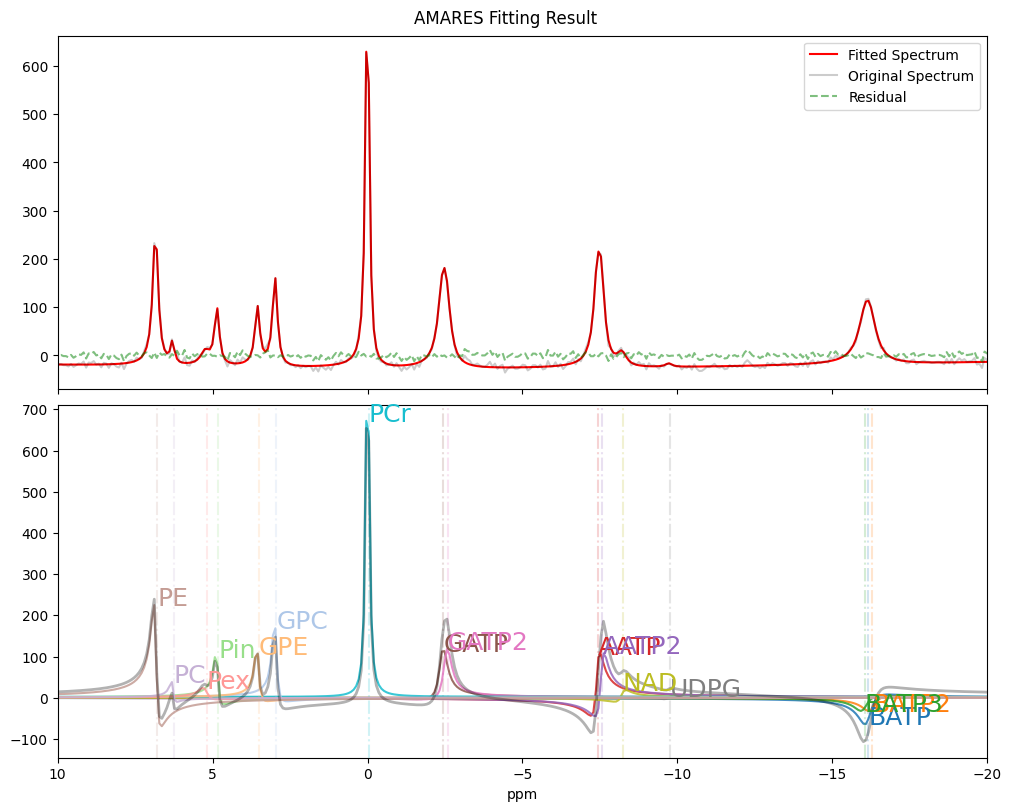

In [23]:
FIDresult3 = pyAMARES.fitAMARES(
    fid_parameters=FIDobj,
    fitting_parameters=initial_params_fixedphase,
    method="least_squares",
    ifplot=True,
    inplace=False,
)

In [24]:
FIDresult3.styled_df

,amplitude,sd,CRLB(%),chem shift(ppm),sd(ppm),CRLB(cs%),LW(Hz),sd(Hz),CRLB(LW%),phase(deg),sd(deg),CRLB(phase%),g,g_sd,g (%),SNR
name,,,,,,,,,,,,,,,,
BATP,2.867,0.057,2.795,-16.171,0.005,0.046,60.332,1.872,4.331,-0.379,0.295,108.632,0.000,0.000,nan,10.953
AATP,3.083,0.048,2.186,-7.449,0.002,0.042,31.226,0.827,3.696,-0.379,0.295,108.632,0.000,0.000,nan,11.780
GATP,3.088,0.047,2.112,-2.451,0.003,0.160,38.948,0.959,3.438,-0.379,0.295,108.632,0.000,0.000,nan,11.797
UDPG,0.071,0.037,72.211,-9.760,0.060,0.859,29.125,20.842,99.900,-0.379,0.295,108.632,0.000,0.000,nan,0.271
NAD,0.372,0.052,19.393,-8.246,0.019,0.327,40.727,7.332,25.132,-0.379,0.295,108.632,0.000,0.000,nan,1.420
PCr,4.456,0.026,0.816,-0.039,0.000,1.787,15.408,0.126,1.144,-0.379,0.295,108.632,0.000,0.000,nan,17.024
GPC,1.334,0.032,3.332,2.940,0.002,0.095,21.026,0.692,4.598,-0.379,0.295,108.632,0.000,0.000,nan,5.097
GPE,0.865,0.032,5.135,3.508,0.003,0.120,20.849,1.056,7.073,-0.379,0.295,108.632,0.000,0.000,nan,3.305
Pin,0.831,0.045,7.624,4.813,0.003,0.093,20.545,1.289,8.758,-0.379,0.295,108.632,0.000,0.000,nan,3.176


- **Convert lmfit Parameter to Pandas DataFrame**:
    - For comparison and easier editing, import functions that enable conversion between an lmfit Parameter object and a Python pandas DataFrame.

In [25]:
from pyAMARES import parameters_to_dataframe

In [26]:
origin = parameters_to_dataframe(params)  # Original parameters
result1 = parameters_to_dataframe(
    FIDresult1.fittedParams
)  # Fitting Result using HSVD initialized parameters
result2 = parameters_to_dataframe(
    FIDresult2.fittedParams
)  # Fitting Result using Levenberg-Marquardt initialized parameters
result3 = parameters_to_dataframe(
    FIDresult3.fittedParams
)  # Fitting Result using fixed phase of all peaks

In [27]:
# Generate index for peak amplitudes only.
amplitude_index = origin.name.str.startswith("ak")
amplitude_index

0      True
1     False
2     False
3     False
4     False
      ...  
75     True
76    False
77    False
78    False
79    False
Name: name, Length: 80, dtype: bool

In [28]:
# Define a function to do linear regression between two lists
import matplotlib.pyplot as plt
import scipy


def compare_plot(x, y, labellist, title="", xlabel="", ylabel=""):
    assert len(x) == len(y) == len(labellist)
    x = x / x[0]
    y = y / y[0]
    plt.scatter(x, y)
    for i, j, l in zip(x, y, labellist):
        plt.annotate(l, (i * 1.02, j * 1.02))

    slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x, y)

    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = slope * x_fit + intercept
    plt.plot(x_fit, y_fit, "r", label="slope=%.3f" % slope)

    combined_min = min(min(x), min(y)) * 0.95
    combined_max = max(max(x), max(y)) * 1.05
    plt.plot(
        [combined_min, combined_max], [combined_min, combined_max], "k--"
    )  # Dashed diagonal line

    # Beautify the plot
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    # plt.axis('equal')  # Use the same scale for both x and y axes

    # Print the results
    print("Slope: %.3f" % slope)
    print("Pearson's R: %.4f" % r_value)
    print("P-value: %.2e" % p_value)
    plt.title("%s r_value=%.2f p_value=%.2f" % (title, r_value, p_value))
    plt.xlim(combined_min, combined_max)
    plt.ylim(combined_min, combined_max)
    plt.legend()
    # Display the plot
    plt.show()

    # Return the slope, Pearson's R, and p-value
    return slope, r_value, p_value

- Now we have three fitting results:
    - `result1`: Fitting result using HSVD-initialized parameters.
    - `result2`: Fitting result using Levenberg-Marquardt-initialized parameters.
    - `result3`: Fitting result with a fixed phase for all peaks.
- Compare them to the ground truth by linear regressions
    - Compare these fitting results to the ground truth using linear regression analyses.


Slope: 1.014
Pearson's R: 0.9996
P-value: 9.41e-23


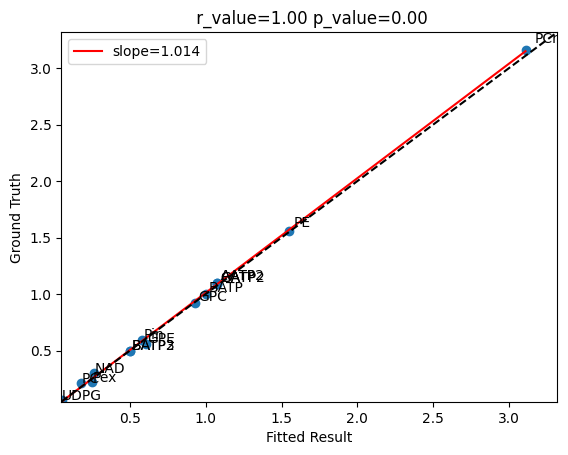

(np.float64(1.0138256166466013),
 np.float64(0.9995539688134767),
 np.float64(9.405575148487986e-23))

In [29]:
compare_plot(
    y=origin[amplitude_index]["value"],
    x=result1[amplitude_index]["value"],
    labellist=FIDresult1.peaklist,
    xlabel="Fitted Result",
    ylabel="Ground Truth",
)

Slope: 1.014
Pearson's R: 0.9996
P-value: 9.66e-23


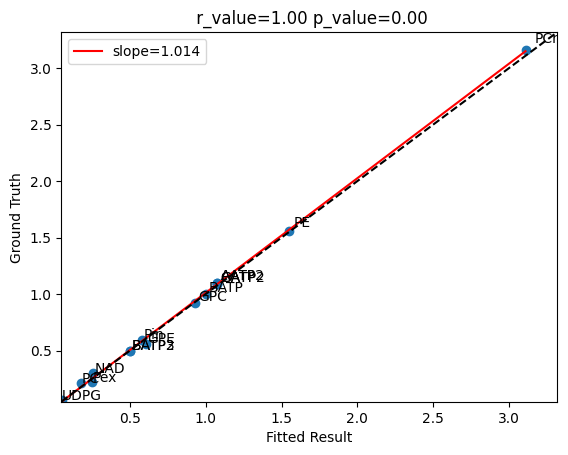

(np.float64(1.013773556891806),
 np.float64(0.999552240556678),
 np.float64(9.66362536676026e-23))

In [30]:
compare_plot(
    x=result2[amplitude_index]["value"],
    y=origin[amplitude_index]["value"],
    labellist=FIDresult1.peaklist,
    xlabel="Fitted Result",
    ylabel="Ground Truth",
)

Slope: 1.014
Pearson's R: 0.9996
P-value: 9.66e-23


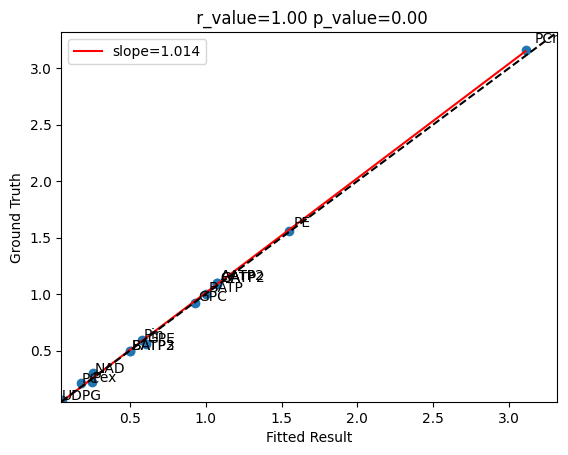

(np.float64(1.0137735576536122),
 np.float64(0.9995522405666346),
 np.float64(9.66362386281831e-23))

In [31]:
compare_plot(
    x=result3[amplitude_index]["value"],
    y=origin[amplitude_index]["value"],
    labellist=FIDresult1.peaklist,
    xlabel="Fitted Result",
    ylabel="Ground Truth",
)